In [9]:
import pandas as pd
train = pd.read_csv('train.csv')
store = pd.read_csv('store.csv')
print(train.shape)
print(train.head())

C:\Users\Khushi Chaudhari\AppData\Local\Temp\ipykernel_5488\370732822.py:2: DtypeWarning: Columns (7: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train.csv')


(1017209, 9)
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  


In [10]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB
None


In [13]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


In [14]:
train['Date'] = pd.to_datetime(train['Date'])

In [15]:
print(train['Date'].dtype)

datetime64[us]


In [11]:
print(train.isnull().sum())

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


In [12]:
print(train.describe())

              Store     DayOfWeek         Sales     Customers          Open  \
count  1.017209e+06  1.017209e+06  1.017209e+06  1.017209e+06  1.017209e+06   
mean   5.584297e+02  3.998341e+00  5.773819e+03  6.331459e+02  8.301067e-01   
std    3.219087e+02  1.997391e+00  3.849926e+03  4.644117e+02  3.755392e-01   
min    1.000000e+00  1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    2.800000e+02  2.000000e+00  3.727000e+03  4.050000e+02  1.000000e+00   
50%    5.580000e+02  4.000000e+00  5.744000e+03  6.090000e+02  1.000000e+00   
75%    8.380000e+02  6.000000e+00  7.856000e+03  8.370000e+02  1.000000e+00   
max    1.115000e+03  7.000000e+00  4.155100e+04  7.388000e+03  1.000000e+00   

              Promo  SchoolHoliday  
count  1.017209e+06   1.017209e+06  
mean   3.815145e-01   1.786467e-01  
std    4.857586e-01   3.830564e-01  
min    0.000000e+00   0.000000e+00  
25%    0.000000e+00   0.000000e+00  
50%    0.000000e+00   0.000000e+00  
75%    1.000000e+00   0.00000

In [16]:
print("Start Date:", train['Date'].min())
print("End Date:", train['Date'].max())

Start Date: 2013-01-01 00:00:00
End Date: 2015-07-31 00:00:00


In [17]:
print("Number of Stores:", train['Store'].nunique())

Number of Stores: 1115


In [18]:
store_date_range = train.groupby('Store')['Date'].agg(['min', 'max'])

print(store_date_range.head())
print("Stores:", len(store_date_range))

             min        max
Store                      
1     2013-01-01 2015-07-31
2     2013-01-01 2015-07-31
3     2013-01-01 2015-07-31
4     2013-01-01 2015-07-31
5     2013-01-01 2015-07-31
Stores: 1115


In [19]:
print(store_date_range['min'].value_counts().head())
print(store_date_range['max'].value_counts().head())

min
2013-01-01    1114
2013-01-02       1
Name: count, dtype: int64
max
2015-07-31    1115
Name: count, dtype: int64


In [20]:
all_dates = pd.date_range(
    start=train['Date'].min(),
    end=train['Date'].max(),
    freq='D'
)

missing_dates = all_dates.difference(train['Date'].unique())

print("Expected dates:", len(all_dates))
print("Missing dates:", len(missing_dates))
print(missing_dates)

Expected dates: 942
Missing dates: 0
DatetimeIndex([], dtype='datetime64[us]', freq='D')


In [21]:
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Day'] = train['Date'].dt.day

In [22]:
print(train[['Date', 'Year', 'Month', 'Day']].head())

        Date  Year  Month  Day
0 2015-07-31  2015      7   31
1 2015-07-31  2015      7   31
2 2015-07-31  2015      7   31
3 2015-07-31  2015      7   31
4 2015-07-31  2015      7   31


In [23]:
train['WeekOfYear'] = train['Date'].dt.isocalendar().week

In [24]:
print(train[['Date', 'DayOfWeek', 'WeekOfYear']].head())

        Date  DayOfWeek  WeekOfYear
0 2015-07-31          5          31
1 2015-07-31          5          31
2 2015-07-31          5          31
3 2015-07-31          5          31
4 2015-07-31          5          31


In [25]:
day_sales = train.groupby('DayOfWeek')['Sales'].mean()

print(day_sales)

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64


In [26]:
open_sales = train.groupby('Open')['Sales'].agg(['count', 'mean', 'sum'])

print(open_sales)

       count         mean         sum
Open                                 
0     172817     0.000000           0
1     844392  6955.514291  5873180623


In [27]:
day_sales_open = train[train['Open'] == 1].groupby('DayOfWeek')['Sales'].mean()

print(day_sales_open)

DayOfWeek
1    8216.073074
2    7088.113656
3    6728.122978
4    6767.310159
5    7072.677012
6    5874.840238
7    8224.723908
Name: Sales, dtype: float64


In [28]:
sunday_open = train[train['DayOfWeek'] == 7].groupby('Open').size()

print(sunday_open)

Open
0    141137
1      3593
dtype: int64


In [29]:
monthly_sales = train[train['Open'] == 1].groupby(
    train['Date'].dt.to_period('M')
)['Sales'].mean()

print(monthly_sales)

Date
2013-01    6239.641380
2013-02    6428.597796
2013-03    7212.834110
2013-04    6579.319656
2013-05    7076.217960
2013-06    6467.051428
2013-07    6923.154611
2013-08    6595.927627
2013-09    6363.388121
2013-10    6473.347016
2013-11    6904.509503
2013-12    8613.455299
2014-01    6539.402563
2014-02    6678.038182
2014-03    6654.021442
2014-04    7226.782207
2014-05    6948.119518
2014-06    7250.660066
2014-07    6891.479689
2014-08    6714.305191
2014-09    6756.588279
2014-10    6757.320303
2014-11    7539.603854
2014-12    8603.805210
2015-01    6913.177694
2015-02    6660.270408
2015-03    7071.240818
2015-04    7349.110170
2015-05    7308.496793
2015-06    7295.618795
2015-07    7033.344905
Freq: M, Name: Sales, dtype: float64


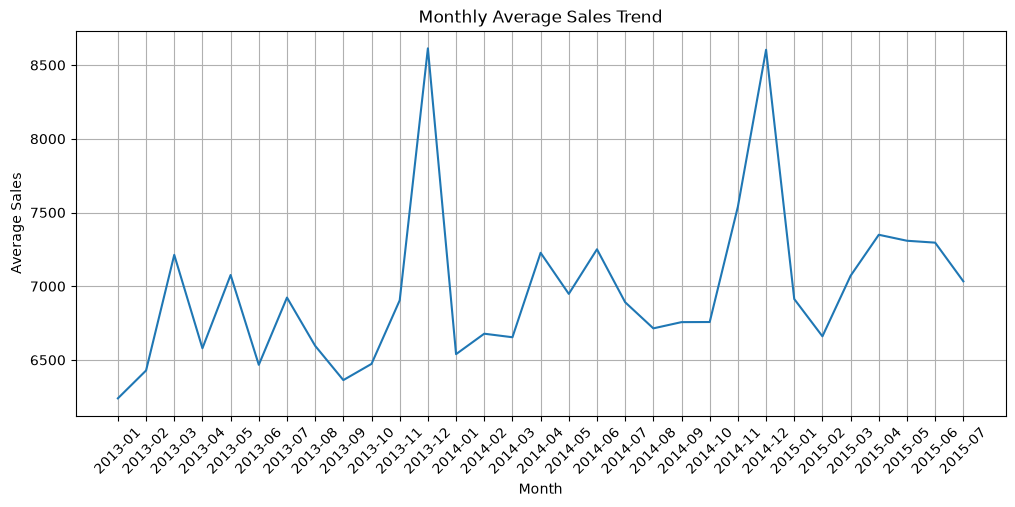

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.title("Monthly Average Sales Trend")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [32]:
promo_sales = train[train['Open'] == 1].groupby('Promo')['Sales'].agg(
    ['count', 'mean', 'sum']
)

print(promo_sales)

        count         mean         sum
Promo                                 
0      467496  5929.407603  2771974337
1      376896  8228.281239  3101206286


In [33]:
customer_sales = train[train['Open'] == 1][['Customers', 'Sales']]

print(customer_sales.describe())

           Customers          Sales
count  844392.000000  844392.000000
mean      762.728395    6955.514291
std       401.227674    3104.214680
min         0.000000       0.000000
25%       519.000000    4859.000000
50%       676.000000    6369.000000
75%       893.000000    8360.000000
max      7388.000000   41551.000000


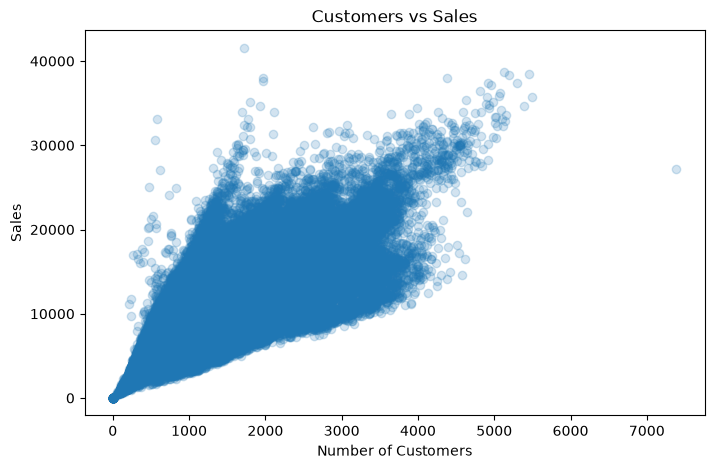

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.scatter(customer_sales['Customers'], customer_sales['Sales'], alpha=0.2)

plt.xlabel("Number of Customers")
plt.ylabel("Sales")
plt.title("Customers vs Sales")

plt.show()

In [35]:
correlation = customer_sales['Customers'].corr(customer_sales['Sales'])

print("Correlation between Customers and Sales:", correlation)

Correlation between Customers and Sales: 0.8235967321975463


In [36]:
print(store.shape)
print(store.info())
print(store.head())

(1115, 10)
<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB
None
   Store StoreType Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0      1         c          a               1270.0                        9.

In [37]:
print(store.isnull().sum())

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [38]:
df = train.merge(store, on='Store', how='left')


In [39]:
print(df.shape)
print(df.head())
print(df.isnull().sum())

(1017209, 22)
   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5 2015-07-31   5263        555     1      1            0   
1      2          5 2015-07-31   6064        625     1      1            0   
2      3          5 2015-07-31   8314        821     1      1            0   
3      4          5 2015-07-31  13995       1498     1      1            0   
4      5          5 2015-07-31   4822        559     1      1            0   

   SchoolHoliday  Year  ...  WeekOfYear  StoreType  Assortment  \
0              1  2015  ...          31          c           a   
1              1  2015  ...          31          a           a   
2              1  2015  ...          31          a           a   
3              1  2015  ...          31          c           c   
4              1  2015  ...          31          a           a   

  CompetitionDistance CompetitionOpenSinceMonth  CompetitionOpenSinceYear  \
0              1270.0                      

In [40]:
store_type_sales = df[df['Open'] == 1].groupby('StoreType')['Sales'].agg(['count', 'mean', 'sum'])

print(store_type_sales)

            count          mean         sum
StoreType                                  
a          457077   6925.167661  3165334859
b           15563  10231.407505   159231395
c          112978   6932.512755   783221426
d          258774   6822.141881  1765392943


In [41]:
assortment_sales = (
    df[df['Open'] == 1]
    .groupby('Assortment')['Sales']
    .agg(['count', 'mean', 'sum'])
)

print(assortment_sales)

             count         mean         sum
Assortment                                 
a           444909  6621.017039  2945750070
b             8212  8639.346322    70946312
c           391271  7300.526339  2856484241


In [42]:
df['CompetitionDistance'].describe()

count    1.014567e+06
mean     5.430086e+03
std      7.715324e+03
min      2.000000e+01
25%      7.100000e+02
50%      2.330000e+03
75%      6.890000e+03
max      7.586000e+04
Name: CompetitionDistance, dtype: float64

In [44]:
df['CompetitionRange'] = pd.cut(
    df['CompetitionDistance'],
    bins=[0, 1000, 5000, 10000, float('inf')],
    labels=['<1 km', '1–5 km', '5–10 km', '10+ km']
)

In [45]:
competition_sales = (
    df[df['Open'] == 1]
    .groupby('CompetitionRange', observed=True)['Sales']
    .agg(['count', 'mean', 'sum'])
)

print(competition_sales)


                   count         mean         sum
CompetitionRange                                 
<1 km             250959  7301.654210  1832415839
1–5 km            326725  6836.022135  2233499332
5–10 km           121911  6742.587896   821995633
10+ km            142611  6824.760993   973285990


In [46]:
school_holiday_sales = (
    df[df['Open'] == 1]
    .groupby('SchoolHoliday')['Sales']
    .agg(['count', 'mean', 'sum'])
)

print(school_holiday_sales)

                count         mean         sum
SchoolHoliday                                 
0              680935  6896.782411  4696260531
1              163457  7200.181650  1176920092


In [49]:
store_performance = (
    df[df['Open'] == 1]
    .groupby('Store')['Sales']
    .agg(['count', 'mean', 'sum'])
    .sort_values('mean', ascending=False)
)

print(store_performance.head(10))

       count          mean       sum
Store                               
817      784  21757.483418  17057867
262      942  20718.515924  19516842
1114     784  20666.562500  16202585
251      779  19123.068036  14896870
842      622  18574.795820  11553523
513      784  18179.089286  14252406
562      942  17969.556263  16927322
788      784  17961.914541  14082141
383      780  17294.716667  13489879
756      779  16574.816431  12911782


In [50]:
print(store_performance.sort_values('mean').head(10))

       count         mean      sum
Store                             
307      782  2703.736573  2114322
543      781  2790.380282  2179287
198      782  2900.604859  2268273
208      784  2936.290816  2302052
841      780  2972.608974  2318635
254      779  3005.983312  2341661
794      780  3083.812821  2405374
219      779  3133.712452  2441162
210      779  3193.984596  2488114
425      776  3237.659794  2512424


In [51]:
store_sales = (
    df[df['Store'] == 817]
    .sort_values('Date')[['Date', 'Sales', 'Open']]
)

print(store_sales.head())
print(store_sales.tail())
print(store_sales.shape)

              Date  Sales  Open
1016911 2013-01-01      0     0
1015796 2013-01-02  25357     1
1014681 2013-01-03  23303     1
1013566 2013-01-04  21996     1
1012451 2013-01-05  15442     1
           Date  Sales  Open
5276 2015-07-27  23932     1
4161 2015-07-28  23248     1
3046 2015-07-29  21556     1
1931 2015-07-30  22177     1
816  2015-07-31  23093     1
(942, 3)


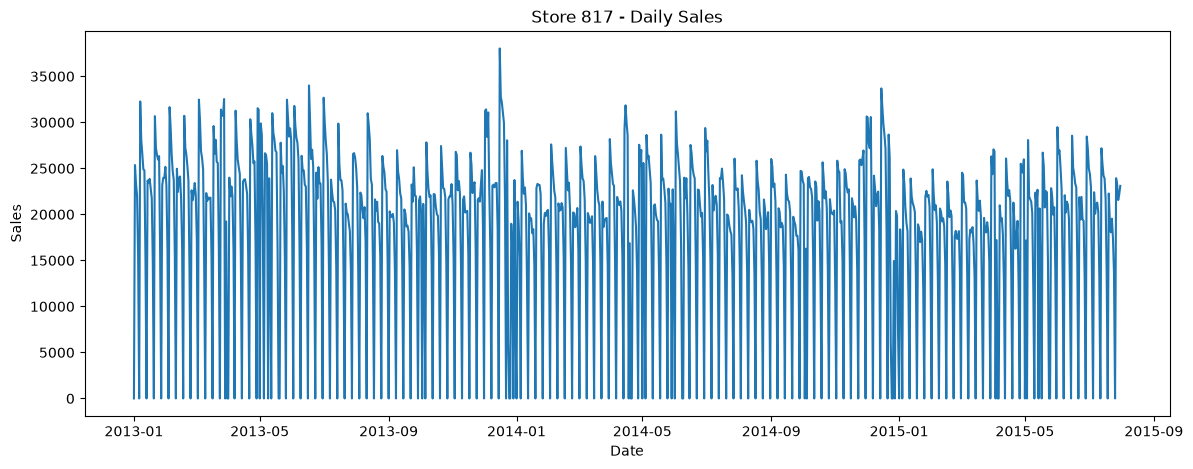

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.plot(store_sales['Date'], store_sales['Sales'])

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Store 817 - Daily Sales")

plt.show()

In [53]:
store_sales['Open'].value_counts()

Open
1    784
0    158
Name: count, dtype: int64

In [54]:
store_sales[store_sales['Open'] == 0]

,Date,Sales,Open
1016911,2013-01-01,0,0
1011336,2013-01-06,0,0
1003531,2013-01-13,0,0
995726,2013-01-20,0,0
987921,2013-01-27,0,0
...,...,...,...
37611,2015-06-28,0,0
29806,2015-07-05,0,0
22001,2015-07-12,0,0
14196,2015-07-19,0,0


In [55]:
store_sales[store_sales['Open'] == 0]['Date'].dt.day_name().value_counts()


store_sales[store_sales['Open'] == 1]['Date'].dt.day_name().value_counts()

Date
Saturday     134
Tuesday      134
Wednesday    132
Friday       129
Monday       128
Thursday     127
Name: count, dtype: int64

In [56]:
store_sales[store_sales['Open'] == 1]['Date'].dt.day_name().value_counts()

Date
Saturday     134
Tuesday      134
Wednesday    132
Friday       129
Monday       128
Thursday     127
Name: count, dtype: int64

In [57]:
forecast_data = store_sales[store_sales['Open'] == 1].copy()

forecast_data = forecast_data[['Date', 'Sales']]

print(forecast_data.head())
print(forecast_data.tail())
print(forecast_data.shape)

              Date  Sales
1015796 2013-01-02  25357
1014681 2013-01-03  23303
1013566 2013-01-04  21996
1012451 2013-01-05  15442
1010221 2013-01-07  32263
           Date  Sales
5276 2015-07-27  23932
4161 2015-07-28  23248
3046 2015-07-29  21556
1931 2015-07-30  22177
816  2015-07-31  23093
(784, 2)


In [58]:
split_index = int(len(forecast_data) * 0.8)

train_data = forecast_data.iloc[:split_index].copy()
test_data = forecast_data.iloc[split_index:].copy()

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

print("\nTraining period:")
print(train_data['Date'].min(), "to", train_data['Date'].max())

print("\nTesting period:")
print(test_data['Date'].min(), "to", test_data['Date'].max())


Training observations: 627
Testing observations: 157

Training period:
2013-01-02 00:00:00 to 2015-01-23 00:00:00

Testing period:
2015-01-24 00:00:00 to 2015-07-31 00:00:00
